# Working With Profile Data

In this tutorial, we are going to compute stacked profiles for a few different quantities.

The "sodpropertybins" dataset contains pre-computed profiles of a number of quantities for each identified halo. You can access this data by opening the profile dataset with the halo properties dataset in a collection.

In [10]:
%matplotlib inline
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt

ds = oc.open("halos_and_profiles.hdf5").filter(oc.col("sod_halo_mass") > 5e14).take(100, at="start")
print(ds)

Collection of halos with halo_profiles and halo_properties


There are a number of profiles that are available in this dataset, each of which is computed in radial shells centered on the halo's potential minimum (i.e. "sod_halo_center_<x/y/z>" in the haloproperties dataset).

In [11]:
for c in ds["halo_profiles"].columns: print(c)

sod_halo_bin_hot_gas_entropy_ew_sig
unique_tag
sod_halo_bin_hot_gas_ne_ew_sig
sod_halo_bin_rad_vel
sod_halo_bin_gas_pthermal
sod_halo_bin_gas_entropy_sig
sod_halo_bin_gas_pkinetic_sig
sod_halo_bin_wind_fraction
block
sod_halo_bin_hot_gas_lumin_bolo
sod_halo_bin_gas_entropy
sod_halo_bin_star_fraction
sod_halo_bin_cdm_fraction
sod_halo_bin_zmet
sod_halo_bin_gas_pkinetic
fof_halo_bin_tag
sod_halo_bin_sfgas_fraction
sod_halo_bin_gas_ne_sig
sod_halo_bin_gas_temperature
sod_halo_bin_hot_gas_entropy_ew
sod_halo_bin_gas_ne
sod_halo_bin_hot_gas_ne_ew
sod_halo_bin_mass
sod_halo_bin_yhe
sod_halo_bin_gas_pthermal_sig
sod_halo_bin_radius
sod_halo_bin_hot_gas_temp_ew_sig
sod_halo_bin_zmet_sig
sod_halo_bin_rad_vel_sig
sod_halo_bin_norm_gas_YSZ
sod_halo_bin_yhe_sig
sod_halo_bin_hot_gas_temp_ew
sod_halo_bin_gas_temperature_sig
sod_halo_bin_gas_fraction
sod_halo_bin_count


Let's inspect some individual profiles. In this case, we will look at "sod_halo_bin_radius", which stores the upper edge of each radial bin.

In [12]:
rprof = ds["halo_profiles"].get_data()["sod_halo_bin_radius"]

print(np.shape(rprof)) # (N_halos, N_bins)

(100, 51)


In [13]:
# Look at profile for a single halo
print(rprof[0])

[0.01847473 0.02063536 0.02304867 0.02574423 0.02875503 0.03211794
 0.03587415 0.04006965 0.04475582 0.04999003 0.0558364  0.06236649
 0.06966028 0.0778071  0.08690668 0.09707046 0.10842289 0.12110301
 0.13526605 0.1510855  0.16875504 0.18849105 0.21053515 0.23515731
 0.2626591  0.29337722 0.32768783 0.3660111  0.40881634 0.4566275
 0.5100303  0.56967866 0.63630295 0.7107189  0.79383785 0.8866777
 0.9903749  1.1061997  1.2355705  1.3800712  1.5414714  1.7217473
 1.9231064  2.148015   2.3992264  2.679816   2.993222   3.3432808
 3.7342796  4.1710057  4.658807  ] Mpc


Notice that the radial bins are in units of Mpc. If you are making, for example, stacked profiles, you may want to normalize "sod_halo_bin_radius" by $R_\mathrm{200c}$ before stacking.

In [14]:
R200c = ds["halo_properties"].select("sod_halo_radius").get_data()
print(rprof[0]/R200c[0])

[0.01101461 0.01230277 0.01374159 0.01534868 0.01714371 0.01914868
 0.02138812 0.02388948 0.02668337 0.029804   0.03328959 0.03718283
 0.04153138 0.0463885  0.05181365 0.05787329 0.06464159 0.07220147
 0.08064546 0.09007699 0.10061155 0.11237813 0.1255208  0.1402005
 0.15659703 0.17491114 0.19536708 0.21821538 0.2437358  0.27224076
 0.30407947 0.33964172 0.37936303 0.42372975 0.47328514 0.52863616
 0.5904603  0.6595149  0.73664564 0.82279676 0.91902333 1.0265036
 1.1465538  1.2806439  1.4304159  1.597703   1.7845553  1.9932599
 2.226373   2.4867485  2.777575  ]


Here is a simple function that takes in a structure collection containing profile data and a profile field to plot (e.g. "sod_halo_bin_mass"), and plots individual profiles for all halos in the collection, as well as the median profile. Profiles are plotted in terms of $r/R_\mathrm{200c}$. The units of the y-axis and other axis settings can be tweaked using the `units` and `ax_set` parameters.

In [15]:
def plot_profiles(
    ds, 
    field,
    units=None,
    ax_set=None,
):

    default_ax_set = {
        "xlabel": r"$r/R_\mathrm{200c}$",
        "ylabel": None,
        "xscale": "log",
        "yscale": "log"
    }

    # merge defaults with user-provided args
    if ax_set is None:
        ax_set = default_ax_set
    else:
        ax_set = {**default_ax_set, **ax_set}  # user overrides defaults

    fig, ax = plt.subplots()

    # plot individual profiles
    for halo in ds.halos():
        # `halo` is a dictionary that contains halo properties and profiles for a single halo
        prof = halo["halo_profiles"].get_data()
        
        f = prof[field]
        
        if units is not None:
            f = f.to(units)
        
        r = prof["sod_halo_bin_radius"] # radius in units of Mpc
    
        # normalize radius by R200c
        r /= halo["halo_properties"]["sod_halo_radius"]
    
        ax.plot(r, f, lw=1, c='k', alpha=0.3)
    
    
    # plot median profile
    profiles = ds["halo_profiles"].get_data()
    R200c = ds["halo_properties"].select("sod_halo_radius").get_data()
    
    median_r = np.nanmedian(profiles["sod_halo_bin_radius"]/R200c[:, None], axis=0)
    median_f = np.nanmedian(profiles[field], axis=0)
    
    ax.plot(median_r, median_f, lw=4, c='r', label="median profile")

    ax.set(**ax_set)

    ax.legend()
    plt.show()    

This function plots individual profiles for all halos in the dataset, along with the median profile for the specified `field`.

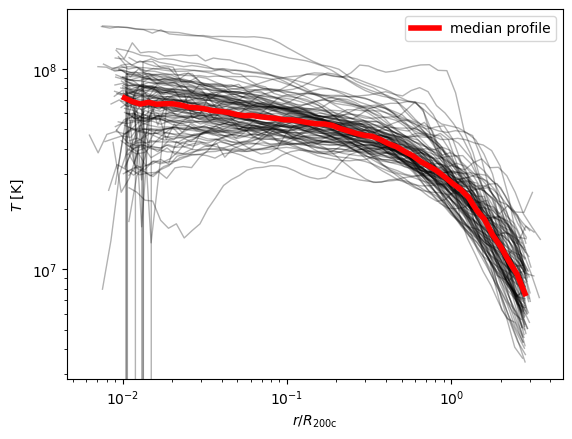

In [16]:
plot_profiles(ds, "sod_halo_bin_gas_temperature", ax_set = {"ylabel": r"$T\ [\mathrm{K}]$"})

# Adding new columns to profile dataset

Derived columns can be added to profile datasets in the same way as any other dataset (e.g. using `with_new_columns`, `evaluate`, or `evaluate_on_dataset`). We will compute a Mach number profile. Because we already have profile data for mass-averaged kinetic and thermal pressure, we can quickly approximate the Mach number as $\mathcal{M}\approx\sqrt{\frac{P_\mathrm{kin}}{\gamma P_\mathrm{therm}}}$.

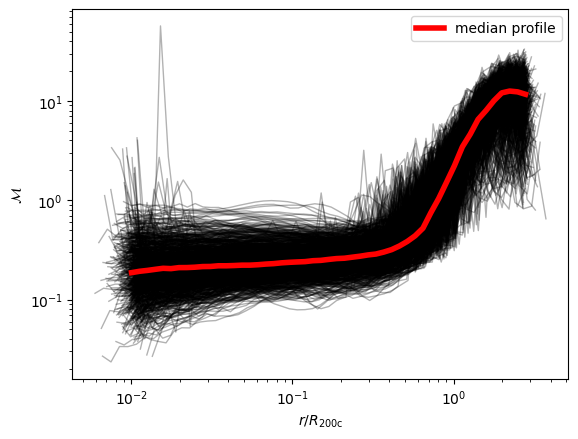

In [17]:
ds = oc.open("halos_and_profiles.hdf5").filter(oc.col("sod_halo_mass") > 5e14)

# compute Mach number and store it as a new column
mach_number = np.sqrt( oc.col("sod_halo_bin_gas_pkinetic") / oc.col("sod_halo_bin_gas_pthermal") / (5/3) )

ds = ds.with_new_columns(mach_number=mach_number, dataset="halo_profiles")

plot_profiles(ds, "mach_number", ax_set = {"ylabel": r"$\mathcal{M}$"})

Let's now compute Mach number profile directly by iterating over gas particles in the halo. Our strategy is to compute the Mach number for each gas particle, and compute a mass-weighted average over the particles in radial bins. 

The Mach number is defined as $$\mathcal{M}=\frac{|\mathbf{v}|}{c_\mathrm{s}}$$ 
where the sound speed is given by 
$$c_\mathrm{s}=\sqrt{\gamma(\gamma-1)\varepsilon_\mathrm{th}}$$
We already have particle data stored for specific internal energy, $\varepsilon_\mathrm{th}$, so we are making things easier for ourselves by computing $c_\mathrm{s}$ in terms of $\varepsilon_\mathrm{th}$.

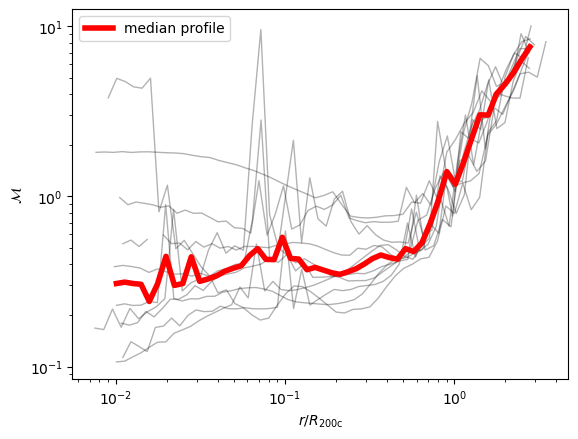

In [18]:
import astropy.units as u

ds = oc.open("halos_particles_and_profiles.hdf5").filter(oc.col("sod_halo_mass") > 5e14).take(10, at="start")

def _mach_number(halo_properties, gas_particles, halo_profiles):
    x0, y0, z0 = halo_properties["sod_halo_com_x"], halo_properties["sod_halo_com_y"], halo_properties["sod_halo_com_z"]
    vx0, vy0, vz0 = halo_properties["sod_halo_com_vx"], halo_properties["sod_halo_com_vy"], halo_properties["sod_halo_com_vz"]

    # normalize particle positions and velocities to halo center of mass
    x, y, z = gas_particles["x"] - x0, gas_particles["y"] - y0, gas_particles["z"] - z0
    vx, vy, vz = gas_particles["vx"] - vx0, gas_particles["vy"] - vy0, gas_particles["vz"] - vz0

    # particle velocity squared -- need it for mach number calculation
    v2 = np.square(vx) + np.square(vy) + np.square(vz)

    m = gas_particles["mass"]
    
    # particle radial positions relative to halo center
    r = np.sqrt(np.square(x) + np.square(y) + np.square(z))
    r_prof = halo_profiles["sod_halo_bin_radius"]
    
    # radial bin width
    delta_r = np.diff(r_prof, prepend=0 * r_prof.unit)
    
    # iterate through radial bins and compute a new profile
    mach_number = []
    for r_bin, delta_r_bin in zip(r_prof, delta_r): #halo_profiles["delta_r"]):
        
        # Filter for particles that are in the current radial bin
        # note that "sod_halo_bin_radius" holds the upper edge of the radial bin
        pfilter = (r_bin-delta_r_bin < r) * (r <= r_bin)

        # cs = sqrt(gamma*(gamma-1)*specific_internal_energy), where gamma = 5/3
        cs2 = 10/9 * gas_particles["uu"][pfilter]

        # mach number for each gas particle
        mach = np.sqrt(v2[pfilter]/cs2)

        # mass-weighted average
        mach_mean = np.sum(m[pfilter] * mach) / np.sum(m[pfilter])
        
        mach_number.append(mach_mean.value)

    return {"mach_number": mach_number * u.dimensionless_unscaled}

    
ds = ds.evaluate(
    _mach_number,
    insert=True,
    halo_properties = [
        "sod_halo_com_x", 
        "sod_halo_com_y", 
        "sod_halo_com_z",
        "sod_halo_com_vx", 
        "sod_halo_com_vy", 
        "sod_halo_com_vz",
    ],
    gas_particles = [
        "x", "y", "z", 
        "vx", "vy", "vz", 
        "uu", "mass",
    ],
    halo_profiles = [
        "sod_halo_bin_radius", "sod_halo_bin_mass",
    ], 
)      


# evaluate currently stores derived columns in the "halo_properties" dataset.
# For consistency, copy the mach number profile into the "halo_propfiles" dataset.
mach_number = ds["halo_properties"].select("mach_number").get_data()
ds = ds.with_new_columns(mach_number = mach_number, dataset="halo_profiles")

plot_profiles(
              ds, 
              "mach_number",
              ax_set = {
                         "ylabel": r"$\mathcal{M}$", 
                         "xscale": "log", 
                         "yscale": "log",
                         #"ylim": [1e-1, 1e1],
              }
)